In [160]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/mcc_codes.json
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/users_data.csv
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/transactions_data.csv
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/cards_data.csv
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/train_fraud_labels.json


In [161]:
transaction = pd.read_csv('/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/transactions_data.csv')

In [164]:
cards = pd.read_csv('/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/cards_data.csv')

In [165]:
transaction = transaction.merge(cards,how = 'left',left_on='card_id', right_on = 'id')

In [166]:
users = pd.read_csv('/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/users_data.csv')

In [167]:
transaction = transaction.merge(users,how = 'left',left_on='client_id_x', right_on = 'id')

In [168]:
mcc = pd.read_json('/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/mcc_codes.json', orient ='index')

In [169]:
mcc = mcc.reset_index()

In [170]:
mcc.columns = ['mcc_code','description']

In [171]:
transaction = transaction.merge(mcc,how = 'left',left_on='mcc', right_on = 'mcc_code')

In [172]:
import json 
with open('/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/train_fraud_labels.json') as f:
    data =json.load(f)
labels = data['target']

In [173]:
fraud = pd.Series(labels)

In [174]:
fraud =fraud.reset_index()

In [175]:
fraud['index'] = fraud['index'].astype('int64')

In [176]:
transaction = transaction.merge(fraud,how = 'left',left_on = 'id_x',right_on = 'index')

In [177]:
transaction.dropna(subset=['index'], inplace = True)

In [17]:
transaction['date']

0           2010-01-01 00:01:00
1           2010-01-01 00:02:00
2           2010-01-01 00:02:00
4           2010-01-01 00:06:00
5           2010-01-01 00:07:00
                   ...         
13305905    2019-10-31 23:54:00
13305906    2019-10-31 23:54:00
13305910    2019-10-31 23:56:00
13305911    2019-10-31 23:56:00
13305912    2019-10-31 23:57:00
Name: date, Length: 8914963, dtype: object

In [178]:
transaction['date'] = pd.to_datetime(transaction['date'])

In [179]:
transaction['transaction_velocity'] = transaction.groupby(['card_id',transaction['date'].dt.date])['amount'].transform('count')

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
transaction[0].value_counts()

0
No     8901631
Yes      13332
Name: count, dtype: int64

sns.boxplot(x=transaction[0], y=transaction['amount'], data=transaction)
plt.show()

In [59]:
sample = transaction.sample(n=10000, random_state=42)

In [180]:
series = transaction['amount'].str.replace('$', '', regex=False)

In [182]:
transaction.columns


Index([                 'id_x',                  'date',
                 'client_id_x',               'card_id',
                      'amount',              'use_chip',
                 'merchant_id',         'merchant_city',
              'merchant_state',                   'zip',
                         'mcc',                'errors',
                        'id_y',           'client_id_y',
                  'card_brand',             'card_type',
                 'card_number',               'expires',
                         'cvv',              'has_chip',
            'num_cards_issued',          'credit_limit',
              'acct_open_date', 'year_pin_last_changed',
            'card_on_dark_web',                    'id',
                 'current_age',        'retirement_age',
                  'birth_year',           'birth_month',
                      'gender',               'address',
                    'latitude',             'longitude',
           'per_capita_income',

In [186]:
series = pd.to_numeric(series)

In [187]:
transaction['amount'] = series

In [188]:
series = transaction['per_capita_income'].str.replace('$', '', regex=False)
series = pd.to_numeric(series)
transaction['per_capita_income'] = series

In [189]:
series = transaction['yearly_income'].str.replace('$', '', regex=False)
series = pd.to_numeric(series)
transaction['yearly_income'] = series

In [190]:
series = transaction['total_debt'].str.replace('$', '', regex=False)
series = pd.to_numeric(series)
transaction['total_debt'] = series

In [92]:
sample = transaction.sample(n=50000, random_state=42)

In [30]:
sample['log_amount'] = np.log1p(sample['amount'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='0', ylabel='log_amount'>

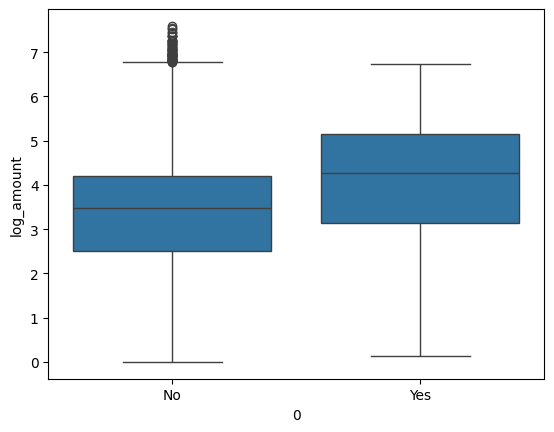

In [31]:
sns.boxplot(x=sample[0], y=sample['log_amount'])

more median amt of fraud than not fraud. very clean looking EDA. still, outliers above the limits. Fraudsters try to make bigger transactions in order to empty/use more money before getting caught.

<Axes: xlabel='0', ylabel='transaction_velocity'>

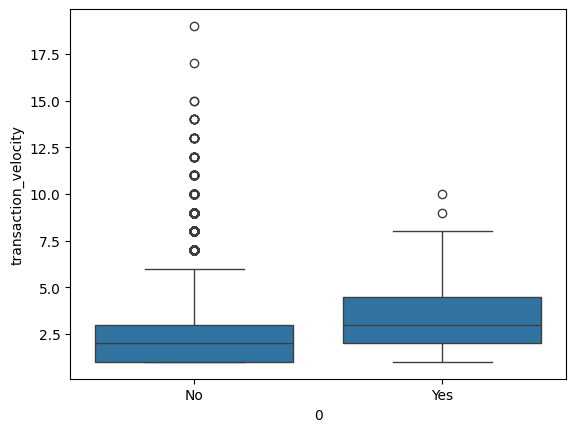

In [32]:
sns.boxplot(x=sample[0], y=sample['transaction_velocity'])

more transactions per unit time in case of fraud. need to remove money before the officers find out.

<Axes: xlabel='0', ylabel='use_chip'>

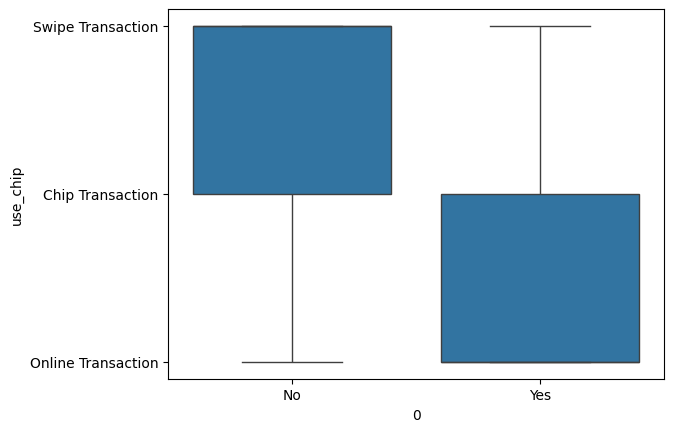

In [33]:
sns.boxplot(x=sample[0], y=sample['use_chip'])

<Axes: xlabel='use_chip', ylabel='0'>

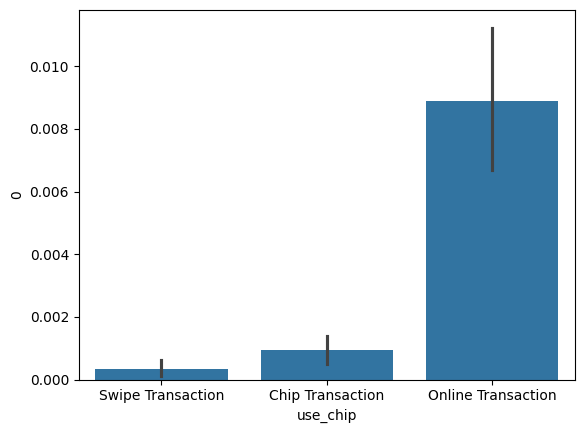

In [34]:
sns.barplot(x='use_chip', y=(sample[0]=='Yes'), data=sample)

ratio on y axis of being fraud

most important, fraud is mostly done in online transactions, easier to hack into and lesser security

<Axes: xlabel='0', ylabel='per_capita_income'>

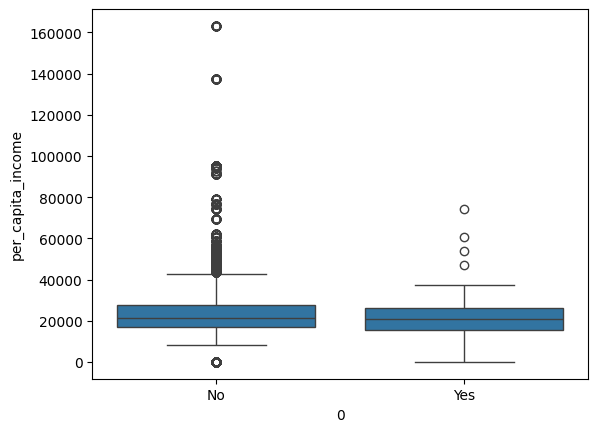

In [35]:
sns.boxplot(x=sample[0], y=sample['per_capita_income'])

<Axes: xlabel='0', ylabel='total_debt'>

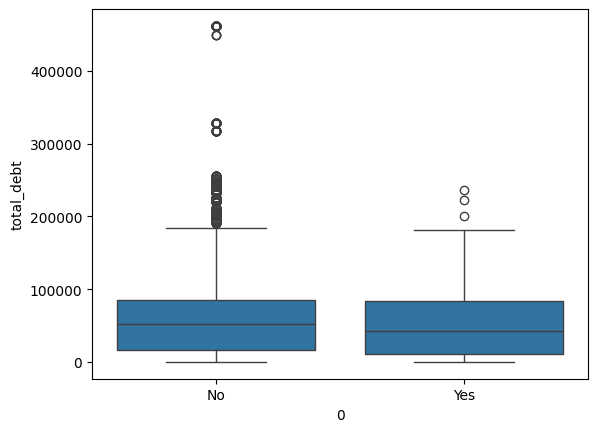

In [36]:
sns.boxplot(x=sample[0], y=sample['total_debt'])

<Axes: xlabel='0', ylabel='credit_score'>

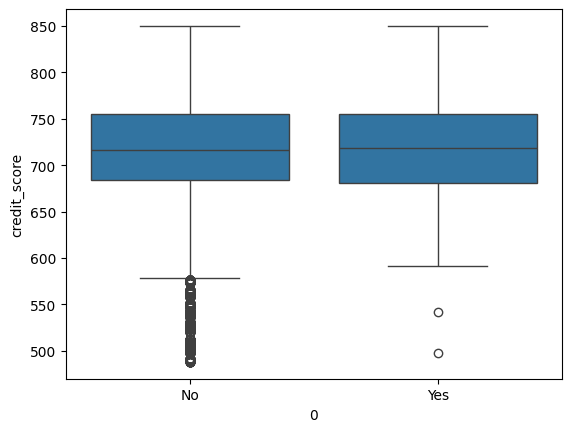

In [37]:
sns.boxplot(x=sample[0], y=sample['credit_score'])

In [93]:
transaction['hour'] = transaction['date'].dt.hour

In [39]:
sample = transaction.sample(n=50000, random_state=42)

<Axes: xlabel='hour', ylabel='0'>

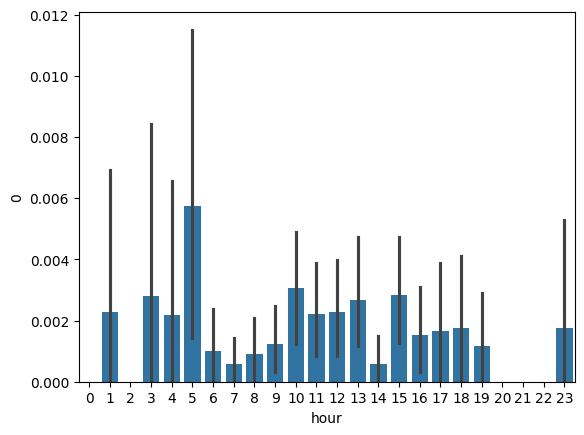

In [40]:
sns.barplot(x='hour', y=(sample[0]=='Yes'), data=sample)

more fraud chance at night when sleeping and wont notice notification

In [41]:
transaction.isnull().sum() 

id_x                           0
date                           0
client_id_x                    0
card_id                        0
amount                         0
use_chip                       0
merchant_id                    0
merchant_city                  0
merchant_state           1047865
zip                      1107377
mcc                            0
errors                   8773196
id_y                           0
client_id_y                    0
card_brand                     0
card_type                      0
card_number                    0
expires                        0
cvv                            0
has_chip                       0
num_cards_issued               0
credit_limit                   0
acct_open_date                 0
year_pin_last_changed          0
card_on_dark_web               0
id                             0
current_age                    0
retirement_age                 0
birth_year                     0
birth_month                    0
gender    

In [42]:
 transaction['errors'].value_counts()

errors
Insufficient Balance                                   87686
Bad PIN                                                21488
Technical Glitch                                       17776
Bad Card Number                                         5235
Bad CVV                                                 4091
Bad Expiration                                          4086
Bad Zipcode                                              767
Bad PIN,Insufficient Balance                             198
Insufficient Balance,Technical Glitch                    163
Bad Card Number,Insufficient Balance                      50
Bad PIN,Technical Glitch                                  44
Bad CVV,Insufficient Balance                              40
Bad Expiration,Insufficient Balance                       34
Bad Card Number,Bad Expiration                            28
Bad Card Number,Bad CVV                                   26
Bad Expiration,Bad CVV                                    21
Bad Expiration,Te

In [191]:
transaction['cvv_exp_cardno'] = (
    transaction['errors'].str.contains('Bad CVV', na=False) |
    transaction['errors'].str.contains('Bad Card Number', na=False) |
    transaction['errors'].str.contains('Bad Expiration', na=False)
)

KeyError: 'errors'

In [44]:
transaction['cvv_exp_cardno'].sample()

13275779    False
Name: cvv_exp_cardno, dtype: bool

In [45]:
sample = transaction.sample(n=50000, random_state=42)

<Axes: xlabel='cvv_exp_cardno', ylabel='0'>

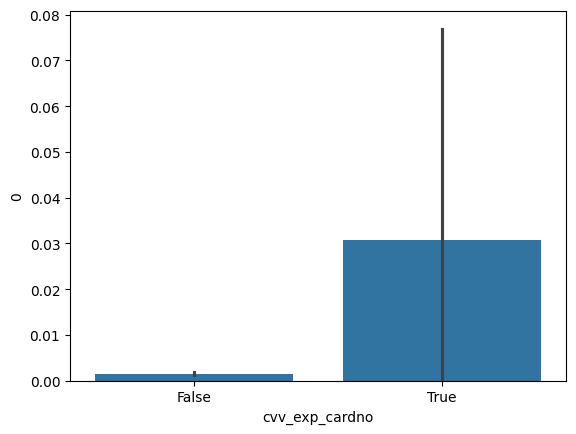

In [46]:
sns.barplot( x=transaction['cvv_exp_cardno'],y=(sample[0]=='Yes') ,data=sample)

In [47]:
transaction['cvv_exp_cardno'].value_counts()

cvv_exp_cardno
False    8901325
True       13638
Name: count, dtype: int64

In [48]:
transaction['card_on_dark_web'].value_counts()

card_on_dark_web
No    8914963
Name: count, dtype: int64

<Axes: xlabel='card_on_dark_web', ylabel='0'>

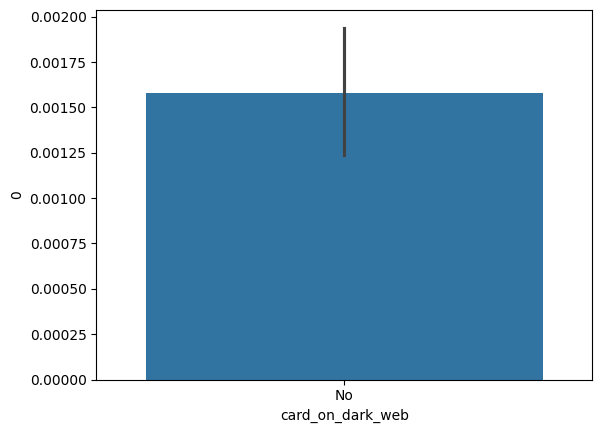

In [49]:
sns.barplot( x=sample['card_on_dark_web'],y=(sample[0]=='Yes') ,data=sample)

In [50]:
transaction.columns

Index([                 'id_x',                  'date',
                 'client_id_x',               'card_id',
                      'amount',              'use_chip',
                 'merchant_id',         'merchant_city',
              'merchant_state',                   'zip',
                         'mcc',                'errors',
                        'id_y',           'client_id_y',
                  'card_brand',             'card_type',
                 'card_number',               'expires',
                         'cvv',              'has_chip',
            'num_cards_issued',          'credit_limit',
              'acct_open_date', 'year_pin_last_changed',
            'card_on_dark_web',                    'id',
                 'current_age',        'retirement_age',
                  'birth_year',           'birth_month',
                      'gender',               'address',
                    'latitude',             'longitude',
           'per_capita_income',

In [95]:
transaction = transaction.drop(columns=['id_x', 'id_y', 'id', 'index','client_id_x', 'client_id_y','card_id', 'merchant_id','card_number', 'cvv','address'])

In [96]:
transaction = transaction.drop(columns = ['mcc_code','description','card_on_dark_web','per_capita_income'])

In [97]:
transaction = transaction.drop(columns = ['card_on_dark_web','per_capita_income'])

KeyError: "['card_on_dark_web', 'per_capita_income'] not found in axis"

In [98]:
transaction['acct_open_date'] = pd.to_datetime(transaction['acct_open_date'])

/tmp/ipykernel_58/1704235773.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transaction['acct_open_date'] = pd.to_datetime(transaction['acct_open_date'])


In [ ]:
transaction['acct_open_date']

In [99]:
transaction['account_age'] = (transaction['date'] - transaction['acct_open_date']).dt.days

In [ ]:
sample = transaction.sample(n=50000, random_state=42)

In [ ]:
sns.boxplot(x=sample[0], y=sample['longitude'])

In [ ]:
sns.boxplot(x=sample[0], y=sample['account_age'])

In [100]:
transaction = transaction.drop(columns=[
    'latitude', 'longitude',
    'birth_year', 'birth_month',
    'current_age', 'retirement_age',
    'yearly_income',
    'total_debt',
    'year_pin_last_changed',
    'acct_open_date', 'account_age',
    'gender'
])

In [ ]:
transaction.columns

In [ ]:
transaction['merchant_city'].nunique()

In [ ]:
transaction['merchant_city'].value_counts().head(15).index

In [ ]:
transaction['merchant_state'].nunique()

In [101]:
transaction=  transaction.drop(columns = ['merchant_city'])

In [102]:
transaction=  transaction.drop(columns = ['errors'])

In [103]:
transaction=  transaction.drop(columns = ['num_cards_issued'])

In [ ]:
transaction.columns

In [104]:
transaction['expires'] = pd.to_datetime(transaction['expires'])

/tmp/ipykernel_58/1386262326.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  transaction['expires'] = pd.to_datetime(transaction['expires'])


In [105]:
transaction['days_to_expiry'] = (transaction['expires'] - transaction['date']).dt.days

In [ ]:
sample = transaction.sample(n=50000, random_state=42)

In [ ]:
sns.boxplot(x=sample[0], y=sample['days_to_expiry'])

In [106]:
transaction=  transaction.drop(columns = ['zip','expires', 'days_to_expiry'])

In [ ]:
transaction['merchant_state'].value_counts().head(15)

In [107]:
top_states = transaction['merchant_state'].value_counts().head(15).index

In [108]:
transaction['merchant_state_grouped'] = transaction['merchant_state'].where(
    transaction['merchant_state'].isin(top_states), 'Other'
)

In [ ]:
transaction['merchant_state_grouped'].value_counts()

In [109]:
transaction = transaction.drop(columns=['merchant_state'])

In [110]:
transaction = pd.get_dummies(transaction, columns=['merchant_state_grouped'],drop_first = True)

In [ ]:
transaction.columns

In [ ]:
transaction['use_chip'].nunique()

In [112]:
transaction = pd.get_dummies(transaction, columns=['use_chip'],drop_first = True)

In [ ]:
transaction['card_type'].nunique()

In [ ]:
transaction['card_type'].sample()

In [113]:
transaction = pd.get_dummies(transaction,columns =['card_type'],drop_first = True)

In [ ]:
transaction['card_brand'].value_counts()

In [114]:
transaction = pd.get_dummies(transaction,columns =['card_brand'],drop_first = True)

In [116]:
mcc_grouped = transaction['mcc'].value_counts().head(15).index

In [117]:
transaction['merchant_grouped'] = transaction['mcc'].where(
    transaction['mcc'].isin(mcc_grouped), 'Other'
)

In [118]:
transaction = transaction.rename(columns={0: 'is_fraud'})

In [119]:
transaction = pd.get_dummies(transaction,columns =['merchant_grouped'],drop_first = True)

In [ ]:
transaction['has_chip'].value_counts()

In [120]:
transaction = pd.get_dummies(transaction,columns =['has_chip'],drop_first = True)

In [135]:
series = transaction['credit_limit'].str.replace('$', '', regex=False)
series = pd.to_numeric(series)
transaction['credit_limit'] = series

In [136]:
y = transaction['is_fraud']

In [137]:
X = transaction.drop(columns=['is_fraud'])

In [138]:
from sklearn.model_selection import train_test_split

X_sorted = X.sort_values('date').drop(columns=['date'])
y_sorted = y[X_sorted.index]

X_train, X_test, y_train, y_test = train_test_split(X_sorted, y_sorted, test_size=0.2, shuffle=False)

In [124]:
transaction.columns

Index(['date', 'amount', 'mcc', 'credit_limit', 'credit_score',
       'num_credit_cards', 'is_fraud', 'transaction_velocity', 'hour',
       'cvv_exp_cardno', 'merchant_state_grouped_FL',
       'merchant_state_grouped_GA', 'merchant_state_grouped_IL',
       'merchant_state_grouped_IN', 'merchant_state_grouped_MI',
       'merchant_state_grouped_NC', 'merchant_state_grouped_NJ',
       'merchant_state_grouped_NY', 'merchant_state_grouped_OH',
       'merchant_state_grouped_Other', 'merchant_state_grouped_PA',
       'merchant_state_grouped_TN', 'merchant_state_grouped_TX',
       'merchant_state_grouped_VA', 'merchant_state_grouped_WA',
       'use_chip_Online Transaction', 'use_chip_Swipe Transaction',
       'card_type_Debit', 'card_type_Debit (Prepaid)', 'card_brand_Discover',
       'card_brand_Mastercard', 'card_brand_Visa', 'merchant_grouped_4784',
       'merchant_grouped_4829', 'merchant_grouped_4900',
       'merchant_grouped_5300', 'merchant_grouped_5310',
       'merchant_

In [194]:
y_test.value_counts()

is_fraud
No     1779876
Yes       3117
Name: count, dtype: int64

In [195]:
from sklearn.preprocessing import StandardScaler

In [196]:
num = ['amount', 'credit_limit', 'credit_score', 'num_credit_cards', 'transaction_velocity', 'hour']

In [197]:
scaler = StandardScaler()
X_train[num] = scaler.fit_transform(X_train[num])
X_test[num] = scaler.transform(X_test[num])

In [198]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [199]:
lr = LogisticRegression(max_iter = 1000, random_state = 17)
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=17)

In [200]:
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      0.99      0.99   1779876
         Yes       0.00      0.02      0.00      3117

    accuracy                           0.98   1782993
   macro avg       0.50      0.50      0.50   1782993
weighted avg       1.00      0.98      0.99   1782993



In [201]:
from sklearn.metrics import precision_recall_curve

y_proba = lr.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba, pos_label='Yes')


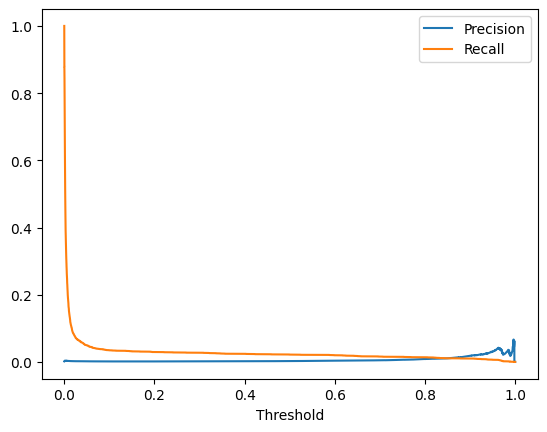

In [202]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [203]:
threshold = 0.02
y_pred_tuned = (y_proba >= threshold).astype(int)

y_test_binary = (y_test == 'Yes').astype(int)
print(classification_report(y_test_binary, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97   1779876
           1       0.00      0.09      0.00      3117

    accuracy                           0.93   1782993
   macro avg       0.50      0.51      0.48   1782993
weighted avg       1.00      0.93      0.96   1782993



In [204]:
y_train_resampled.value_counts()

is_fraud
No     7121755
Yes     712175
Name: count, dtype: int64

In [205]:
print(X_train_resampled.columns.equals(X_test.columns))

True


In [206]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

is_fraud
No     7121755
Yes      10215
Name: count, dtype: int64
is_fraud
No     7121755
Yes     712175
Name: count, dtype: int64


In [209]:
print(X_test.index.equals(y_test.index))

True
